# Scoring Credit Bancaire — Cote d'Ivoire
## Analyse Exploratoire des Donnees
**Contexte :** Prediction du risque de defaut de paiement
pour les clients d'une banque ivoirienne.

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family']    = 'sans-serif'
sns.set_theme(style="darkgrid")

print("Bibliotheques importees !")

Bibliotheques importees !


In [5]:
# Chargement du dataset
df = pd.read_csv(
    r'C:\Users\emman\Documents\Portfolio\credit-scoring-deep-learning\data\cs-training.csv'
)

# Supprimer la colonne inutile
df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset charge !")
print(f"Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"\nColonnes :")
for col in df.columns:
    print(f"  → {col}")

Dataset charge !
Dimensions : 150,000 lignes x 11 colonnes

Colonnes :
  → SeriousDlqin2yrs
  → RevolvingUtilizationOfUnsecuredLines
  → age
  → NumberOfTime30-59DaysPastDueNotWorse
  → DebtRatio
  → MonthlyIncome
  → NumberOfOpenCreditLinesAndLoans
  → NumberOfTimes90DaysLate
  → NumberRealEstateLoansOrLines
  → NumberOfTime60-89DaysPastDueNotWorse
  → NumberOfDependents


In [6]:
# Dictionnaire des variables traduit en contexte ivoirien
dictionnaire = {
    'SeriousDlqin2yrs'          : 'CIBLE : Defaut de paiement (1=oui, 0=non)',
    'RevolvingUtilizationOfUnsecuredLines': 'Taux utilisation credit revolving',
    'age'                        : 'Age du client (annees)',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Retards 30-59 jours',
    'DebtRatio'                  : 'Ratio dette/revenus',
    'MonthlyIncome'              : 'Revenu mensuel (FCFA)',
    'NumberOfOpenCreditLinesAndLoans': 'Nombre de credits ouverts',
    'NumberOfTimes90DaysLate'    : 'Retards +90 jours',
    'NumberRealEstateLoansOrLines': 'Credits immobiliers',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Retards 60-89 jours',
    'NumberOfDependents'         : 'Nombre de personnes a charge',
}

print("Dictionnaire des variables :\n")
for col, desc in dictionnaire.items():
    print(f"  {col}")
    print(f"  → {desc}\n")

Dictionnaire des variables :

  SeriousDlqin2yrs
  → CIBLE : Defaut de paiement (1=oui, 0=non)

  RevolvingUtilizationOfUnsecuredLines
  → Taux utilisation credit revolving

  age
  → Age du client (annees)

  NumberOfTime30-59DaysPastDueNotWorse
  → Retards 30-59 jours

  DebtRatio
  → Ratio dette/revenus

  MonthlyIncome
  → Revenu mensuel (FCFA)

  NumberOfOpenCreditLinesAndLoans
  → Nombre de credits ouverts

  NumberOfTimes90DaysLate
  → Retards +90 jours

  NumberRealEstateLoansOrLines
  → Credits immobiliers

  NumberOfTime60-89DaysPastDueNotWorse
  → Retards 60-89 jours

  NumberOfDependents
  → Nombre de personnes a charge



In [7]:
# Apercu des donnees
print("5 premieres lignes :")
display(df.head())

print("\nInformations generales :")
df.info()

5 premieres lignes :


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0



Informations generales :
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null

In [8]:
# Statistiques descriptives
print("Statistiques descriptives :")
display(df.describe().round(2))

Statistiques descriptives :


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [9]:
# Analyse des valeurs manquantes
manquantes = df.isnull().sum()
pct        = (df.isnull().sum() / len(df) * 100).round(2)

rapport_manquantes = pd.DataFrame({
    'Valeurs manquantes' : manquantes,
    'Pourcentage (%)'    : pct
}).sort_values('Valeurs manquantes', ascending=False)

print("Rapport des valeurs manquantes :\n")
print(rapport_manquantes)

Rapport des valeurs manquantes :

                                      Valeurs manquantes  Pourcentage (%)
MonthlyIncome                                      29731            19.82
NumberOfDependents                                  3924             2.62
SeriousDlqin2yrs                                       0             0.00
age                                                    0             0.00
RevolvingUtilizationOfUnsecuredLines                   0             0.00
DebtRatio                                              0             0.00
NumberOfTime30-59DaysPastDueNotWorse                   0             0.00
NumberOfOpenCreditLinesAndLoans                        0             0.00
NumberOfTimes90DaysLate                                0             0.00
NumberRealEstateLoansOrLines                           0             0.00
NumberOfTime60-89DaysPastDueNotWorse                   0             0.00


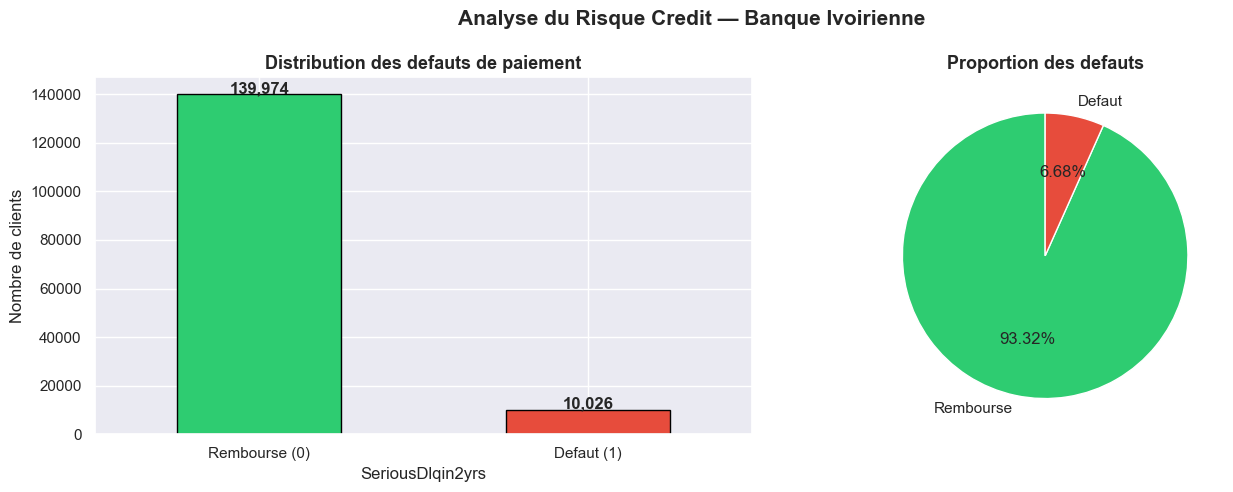

Graphique sauvegarde !


In [10]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comptage
couleurs = ['#2ecc71', '#e74c3c']
counts   = df['SeriousDlqin2yrs'].value_counts()

counts.plot(
    kind='bar',
    ax=axes[0],
    color=couleurs,
    edgecolor='black',
    width=0.5
)
axes[0].set_title(
    'Distribution des defauts de paiement',
    fontsize=13, fontweight='bold'
)
axes[0].set_xticklabels(
    ['Rembourse (0)', 'Defaut (1)'],
    rotation=0
)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts):
    axes[0].text(
        i, v + 500, f'{v:,}',
        ha='center', fontweight='bold'
    )

# Camembert
axes[1].pie(
    counts,
    labels=['Rembourse', 'Defaut'],
    colors=couleurs,
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title(
    'Proportion des defauts',
    fontsize=13, fontweight='bold'
)

plt.suptitle(
    'Analyse du Risque Credit — Banque Ivoirienne',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/01_distribution_defauts.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

Statistiques d'age :

                     count  mean   std   min   25%   50%   75%    max
SeriousDlqin2yrs                                                     
0                 139974.0  52.8  14.8   0.0  42.0  52.0  63.0  109.0
1                  10026.0  45.9  12.9  21.0  36.0  45.0  54.0  101.0


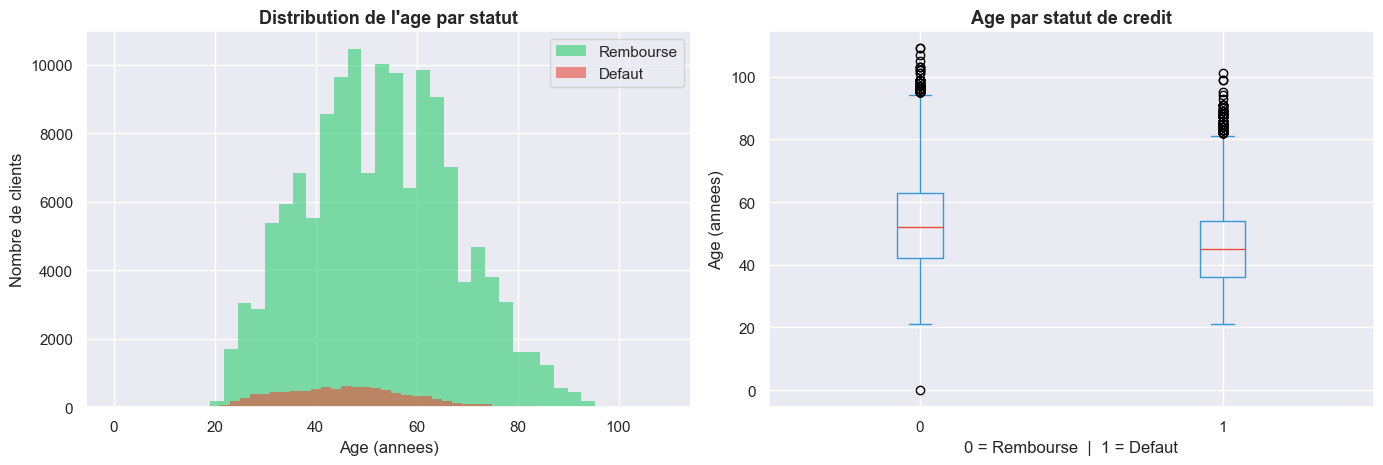


Graphique sauvegarde !


In [11]:
# Distribution de l'age par statut de defaut
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
for statut, couleur, label in zip(
    [0, 1],
    ['#2ecc71', '#e74c3c'],
    ['Rembourse', 'Defaut']
):
    data = df[df['SeriousDlqin2yrs'] == statut]['age']
    axes[0].hist(
        data, bins=40, alpha=0.6,
        color=couleur, label=label,
        edgecolor='none'
    )

axes[0].set_title(
    'Distribution de l\'age par statut',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Age (annees)')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend()

# Boxplot
df.boxplot(
    column='age',
    by='SeriousDlqin2yrs',
    ax=axes[1],
    color=dict(
        boxes='#3498db',
        whiskers='#3498db',
        medians='#e74c3c',
        caps='#3498db'
    )
)
axes[1].set_title(
    'Age par statut de credit',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('0 = Rembourse  |  1 = Defaut')
axes[1].set_ylabel('Age (annees)')
plt.suptitle('')

# Statistiques
print("Statistiques d'age :\n")
print(df.groupby('SeriousDlqin2yrs')['age'].describe().round(1))

plt.tight_layout()
plt.savefig(
    '../reports/02_age_clients.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nGraphique sauvegarde !")

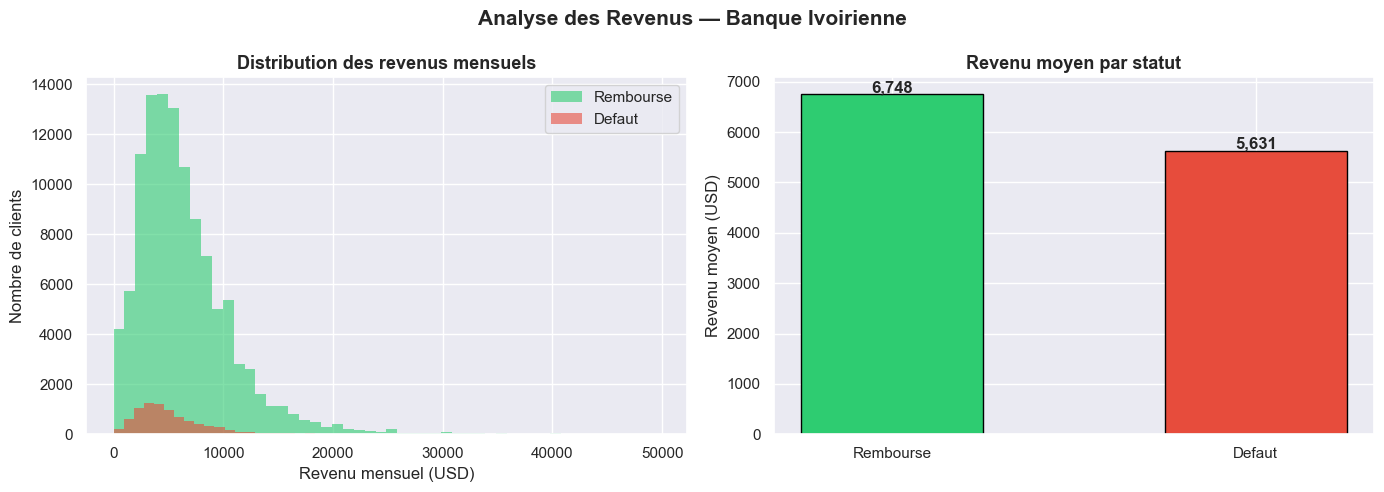

Statistiques des revenus :

                     count    mean      std  min     25%     50%     75%  \
SeriousDlqin2yrs                                                           
0                 111912.0  6748.0  14814.0  0.0  3461.0  5466.0  8333.0   
1                   8357.0  5631.0   6172.0  0.0  2963.0  4500.0  6800.0   

                        max  
SeriousDlqin2yrs             
0                 3008750.0  
1                  250000.0  

Graphique sauvegarde !


In [12]:
# Analyse des revenus mensuels
# Filtrer les valeurs aberrantes
df_revenu = df[df['MonthlyIncome'] < 50000].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des revenus
for statut, couleur, label in zip(
    [0, 1],
    ['#2ecc71', '#e74c3c'],
    ['Rembourse', 'Defaut']
):
    data = df_revenu[
        df_revenu['SeriousDlqin2yrs'] == statut
    ]['MonthlyIncome'].dropna()
    axes[0].hist(
        data, bins=50, alpha=0.6,
        color=couleur, label=label,
        edgecolor='none'
    )

axes[0].set_title(
    'Distribution des revenus mensuels',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Revenu mensuel (USD)')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend()

# Revenu moyen par statut
revenu_moyen = df.groupby(
    'SeriousDlqin2yrs'
)['MonthlyIncome'].mean()

axes[1].bar(
    ['Rembourse', 'Defaut'],
    revenu_moyen.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title(
    'Revenu moyen par statut',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('Revenu moyen (USD)')
for i, v in enumerate(revenu_moyen.values):
    axes[1].text(
        i, v + 50, f'{v:,.0f}',
        ha='center', fontweight='bold'
    )

plt.suptitle(
    'Analyse des Revenus — Banque Ivoirienne',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/03_revenus_clients.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("Statistiques des revenus :\n")
print(df.groupby(
    'SeriousDlqin2yrs'
)['MonthlyIncome'].describe().round(0))
print("\nGraphique sauvegarde !")


In [14]:
# Conversion des revenus en FCFA
TAUX_USD_FCFA = 600

# Creer une nouvelle colonne en FCFA
df['MonthlyIncome_FCFA'] = df['MonthlyIncome'] * TAUX_USD_FCFA

print("Conversion USD → FCFA effectuee !")
print(f"\nTaux utilise : 1 USD = {TAUX_USD_FCFA} FCFA")
print(f"\nStatistiques des revenus en FCFA :")
print(df.groupby('SeriousDlqin2yrs')['MonthlyIncome_FCFA'].describe().round(0))

# Comparaison avec les references ivoiriennes
smic       = 75_000
sal_moyen  = 225_000
sal_cadre  = 700_000

mediane_fcfa = df['MonthlyIncome_FCFA'].median()

print(f"\nContexte ivoirien :")
print(f"  SMIC CI          :   {smic:>12,.0f} FCFA/mois")
print(f"  Salaire moyen CI :   {sal_moyen:>12,.0f} FCFA/mois")
print(f"  Salaire cadre CI :   {sal_cadre:>12,.0f} FCFA/mois")
print(f"  Mediane dataset  :   {mediane_fcfa:>12,.0f} FCFA/mois")

Conversion USD → FCFA effectuee !

Taux utilise : 1 USD = 600 FCFA

Statistiques des revenus en FCFA :
                     count       mean        std  min        25%        50%  \
SeriousDlqin2yrs                                                              
0                 111912.0  4048703.0  8888101.0  0.0  2076600.0  3279600.0   
1                   8357.0  3378496.0  3703032.0  0.0  1777800.0  2700000.0   

                        75%           max  
SeriousDlqin2yrs                           
0                 4999800.0  1.805250e+09  
1                 4080000.0  1.500000e+08  

Contexte ivoirien :
  SMIC CI          :         75,000 FCFA/mois
  Salaire moyen CI :        225,000 FCFA/mois
  Salaire cadre CI :        700,000 FCFA/mois
  Mediane dataset  :      3,240,000 FCFA/mois


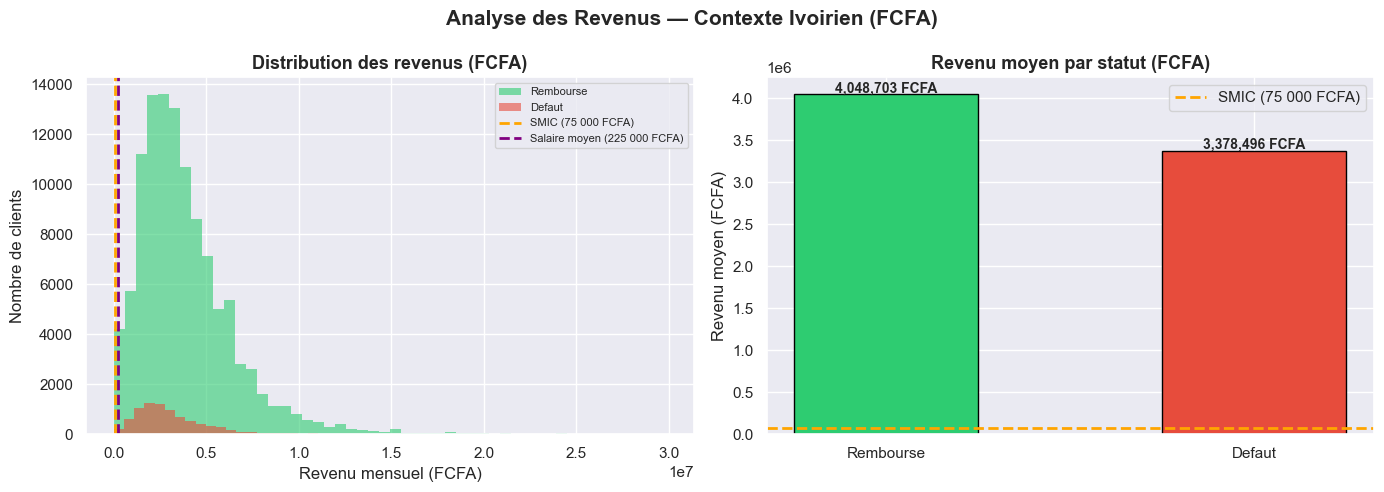

Graphique sauvegarde !


In [15]:
# Visualisation des revenus en FCFA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filtrer les valeurs aberrantes
df_plot = df[df['MonthlyIncome_FCFA'] < 30_000_000].copy()

# Distribution
for statut, couleur, label in zip(
    [0, 1],
    ['#2ecc71', '#e74c3c'],
    ['Rembourse', 'Defaut']
):
    data = df_plot[
        df_plot['SeriousDlqin2yrs'] == statut
    ]['MonthlyIncome_FCFA'].dropna()
    axes[0].hist(
        data, bins=50, alpha=0.6,
        color=couleur, label=label,
        edgecolor='none'
    )

# References ivoiriennes
axes[0].axvline(
    x=75_000, color='orange',
    linestyle='--', linewidth=2,
    label=f'SMIC (75 000 FCFA)'
)
axes[0].axvline(
    x=225_000, color='purple',
    linestyle='--', linewidth=2,
    label=f'Salaire moyen (225 000 FCFA)'
)

axes[0].set_title(
    'Distribution des revenus (FCFA)',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Revenu mensuel (FCFA)')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend(fontsize=8)

# Revenu moyen par statut en FCFA
revenu_moyen_fcfa = df.groupby(
    'SeriousDlqin2yrs'
)['MonthlyIncome_FCFA'].mean()

bars = axes[1].bar(
    ['Rembourse', 'Defaut'],
    revenu_moyen_fcfa.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[1].set_title(
    'Revenu moyen par statut (FCFA)',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('Revenu moyen (FCFA)')

for i, v in enumerate(revenu_moyen_fcfa.values):
    axes[1].text(
        i, v + 20_000,
        f'{v:,.0f} FCFA',
        ha='center', fontweight='bold',
        fontsize=10
    )

# Ligne SMIC
axes[1].axhline(
    y=75_000, color='orange',
    linestyle='--', linewidth=2,
    label='SMIC (75 000 FCFA)'
)
axes[1].legend()

plt.suptitle(
    'Analyse des Revenus — Contexte Ivoirien (FCFA)',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../reports/03_revenus_FCFA.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")

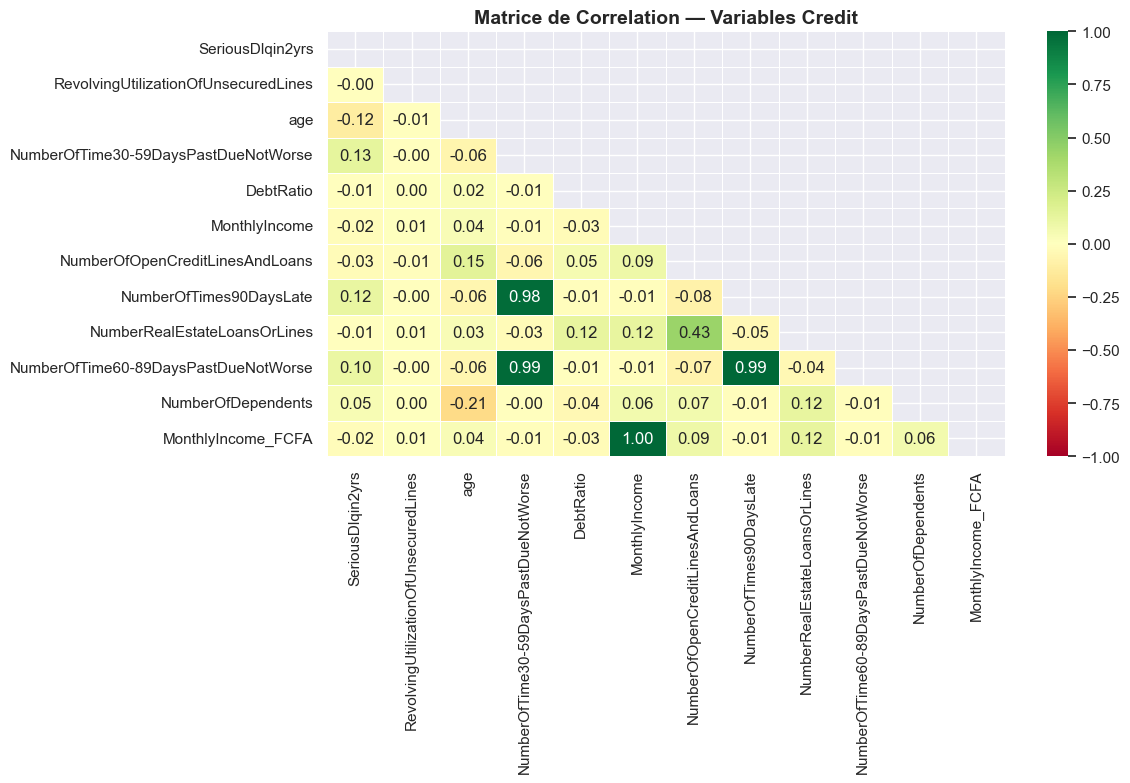

Graphique sauvegarde !


In [16]:
# Matrice de correlation
fig, ax = plt.subplots(figsize=(12, 8))

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    vmin=-1, vmax=1,
    center=0
)

ax.set_title(
    'Matrice de Correlation — Variables Credit',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    '../reports/04_correlation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Graphique sauvegarde !")
